# Livrable 1 — Modélisation formelle du problème
## Optimisation de tournées avec contraintes

**Structure :** CesiCDP  
**Équipe 1 :** ROBIN Thomas, LEDOUX Bastien, LIN Alexandre, FOURFOOZ Luca

---

## Table des matières

1. [Contexte](#1)
2. [Définition informelle du problème](#2)
3. [Représentation formelle des données](#3)
4. [Formulation du problème d'optimisation](#4)
5. [Contraintes supplémentaires retenues](#5)
   - 5.1 [Fenêtres temporelles (Time Windows)](#5-1)
   - 5.2 [Coût et restrictions sur certaines arêtes](#5-2)
6. [Références bibliographiques](#6)

---
## 1. Contexte<a id="1"></a>

### 1.1 Enjeux environnementaux et réglementaires

Pour atteindre l'objectif français de diviser par quatre les émissions de gaz à effet de serre d'ici 2050, le secteur des transports (30% des émissions) est une priorité. 

Dans le cadre d'un appel à projets de l'**ADEME**, notre structure **CesiCDP** a pour mission de concevoir un algorithme d'optimisation de tournées (livraison, collecte). L'enjeu : minimiser l'impact environnemental des flottes de véhicules tout en respectant des contraintes métiers strictes.

### 1.2. Le problème algorithmique en 2 minutes

Derrière cet enjeu se cache le célèbre "Problème du Voyageur de Commerce" avec contraintes (VRP). 
**Le but :** Trouver le meilleur ordre pour visiter une liste d'adresses en perdant le moins de temps et de carburant possible.

La difficulté repose sur **l'explosion combinatoire** : avec seulement 10 adresses, il existe déjà **3 628 800 parcours possibles** (10!). À cela s'ajoutent les réalités du terrain :

* **Fenêtres temporelles :** Le client n'est là qu'entre 14h et 16h.
* **Perturbations :** Une rue est bloquée pour travaux.
* **Capacités :** Le camion ne peut contenir qu'un nombre limité de colis.

### 1.3. Illustration : Le défi de "Livraison-sur-Algorithme"

Imaginons un livreur partant de son entrepôt (**E₀**) à 8h00 pour 6 points (A à F) :

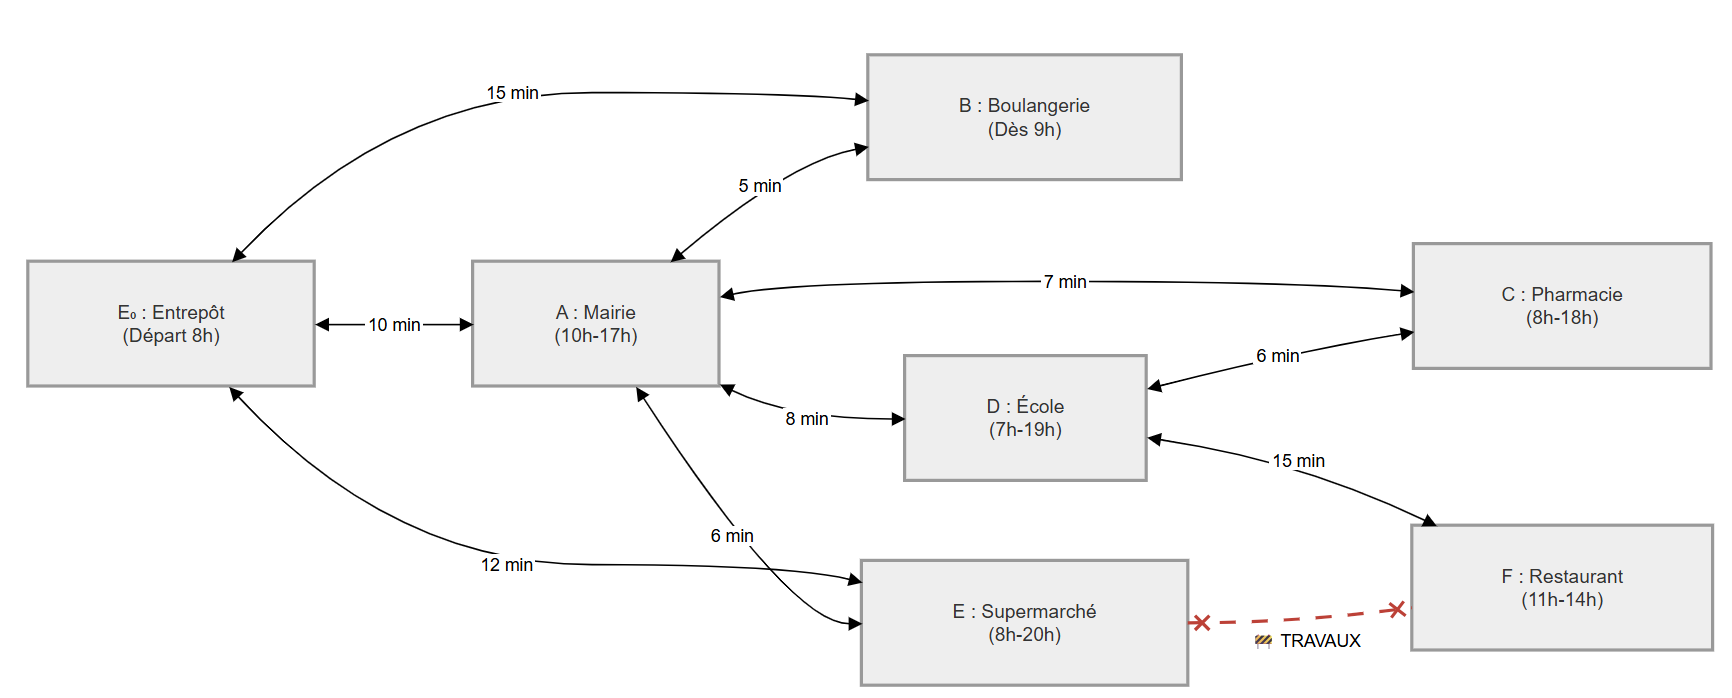

**Le casse-tête :**
* **Mauvais parcours :** `E₀ → E → F`  *Impossible, la route entre E et F est en travaux.*
* **Mauvais parcours :** `E₀ → B` (arrivée à 8h15)  *La boulangerie n'ouvre qu'à 9h !*

### 1.4 Objectif algorithmique

Ce document, qui constitue la première étape de notre réponse à l'ADEME, a pour but de poser les fondations théoriques et pratiques de notre solution. 

Le problème central consiste à **calculer sur un réseau routier une tournée optimale** reliant un sous-ensemble de villes, en revenant au point de départ, de manière à **minimiser la durée totale du trajet**, tout en respectant les contraintes opérationnelles réelles.

Dans ce projet, nous développons des **algorithmes** capables de trouver automatiquement le meilleur parcours, de gérer des centaines de points de livraison et de s'adapter à toutes les contraintes du terrain (horaires, routes bloquées, coûts). À travers ce Notebook, nous allons :

1. **Modéliser mathématiquement** ce problème logistique (Graphes, sommets, arêtes, fonctions de coût).
2. **Intégrer les contraintes complexes** (notamment les fenêtres de temps et les capacités multiples) pour coller à la réalité du terrain.
3. **Analyser la complexité théorique** du problème pour justifier les choix algorithmiques futurs.

**L'objectif final est clair :** Concevoir une intelligence logistique capable de trouver le trajet optimal instantanément pour réduire l'empreinte carbone de nos partenaires. 
**Impact réel :** Moins de kilomètres = moins de carburant = moins de CO₂

---
## 2. Définition informelle du problème <a id="2"></a>

### 2.1 Le problème du Voyageur de Commerce (TSP)

Le problème de base sous-jacent est le célèbre **Travelling Salesman Problem (TSP)**, formulé historiquement par Dantzig, Fulkerson et Johnson en 1954 [1]. Dans sa version classique :

> *Étant donné un ensemble de villes et les distances entre chacune d'elles, trouver le chemin le plus court passant par toutes les villes exactement une fois et revenant à la ville de départ.*

### 2.2 Extension à notre contexte opérationnel

Notre problème s'écarte du TSP classique sur plusieurs points essentiels :

1. **Le graphe n'est pas nécessairement complet** : certaines routes n'existent pas ou sont interdites (travaux, zones à accès restreint).
2. **Les arêtes ont des coûts hétérogènes** : certaines routes sont plus coûteuses (péages, voies dégradées, zones de congestion).
3. **Les villes ont des fenêtres temporelles** : un point de livraison n'est accessible que dans un créneau horaire.

Ce problème enrichi est connu dans la littérature sous le nom de **TSP with Time Windows and Edge Restrictions (TSPTW-R)**.

### 2.3 Un problème intrinsèquement difficile : NP-complétude

Avant d'aller plus loin dans la modélisation, il est essentiel de souligner pourquoi ce problème est **fondamentalement difficile à résoudre**. Le TSPTW-R est un problème **NP-complet**, ce que nous démontrons ici par une chaîne de réductions.

#### Rappels

Un problème est **NP-complet** s'il vérifie deux conditions :
- **∈ NP** : une solution candidate peut être *vérifiée* en temps polynomial.
- **NP-difficile** : tout problème de NP s'y réduit polynomialement — autrement dit, le résoudre efficacement permettrait de résoudre efficacement tous les problèmes de NP.

#### Étape 1 : Le TSP est NP-complet

**TSP ∈ NP :** Étant donné une tournée candidate $\pi = (\pi_1, \ldots, \pi_n)$, on vérifie en $O(n)$ que chaque sommet apparaît exactement une fois et que le coût total est $\leq k$. ✓

**TSP est NP-difficile** (réduction depuis le Circuit Hamiltonien) : Le problème HC — *"existe-t-il un cycle passant par chaque sommet exactement une fois dans un graphe non pondéré $G=(V,E)$ ?"* — est NP-complet (Karp, 1972 [6]). On lui associe l'instance TSP suivante :

$$w'(i,j) = \begin{cases} 0 & \text{si } (i,j) \in E \\ 1 & \text{sinon} \end{cases} \qquad k = 0$$

Cette construction est polynomiale ($O(n^2)$). La double implication est immédiate :
- Si $G$ a un circuit hamiltonien, ce circuit a un coût $0$ dans l'instance TSP → réponse **OUI**.
- Si une tournée de coût $\leq 0$ existe dans l'instance TSP, tous ses poids valent $0$, donc toutes ses arêtes sont dans $E$ → circuit hamiltonien dans $G$ → réponse **OUI**.

Donc **HC $\leq_P$ TSP**, et le TSP est NP-complet.

#### Étape 2 : Le TSPTW-R est NP-complet par généralisation

Le TSP est un cas particulier du TSPTW-R : il suffit de poser $a_i=0,\, b_i=+\infty,\, s_i=0$ pour tout sommet (fenêtres infinies) et $c(i,j)=1$ pour toute arête (aucune restriction). Ces transformations sont en $O(n)$. Donc :

$$\text{HC} \leq_P \text{TSP} \leq_P \text{TSPTW-R}$$

Une solution de TSPTW-R se vérifie en $O(n)$ (ordre de visite, fenêtres, restrictions, coût). Donc TSPTW-R $\in$ NP.

$$\boxed{\text{TSPTW-R est NP-complet}}$$

---
## 3. Représentation formelle des données <a id="3"></a>

### 3.1 Structure de graphe

Le réseau routier est modélisé par un **graphe orienté pondéré** :

$$G = (V, E, w, c)$$

où :

| Symbole | Type | Définition |
|---|---|---|
| $V$ | Ensemble fini | Ensemble des $n$ sommets (villes / points de livraison) |
| $E \subseteq V \times V$ | Ensemble d'arêtes | Routes existantes entre les villes |
| $w : E \rightarrow \mathbb{R}^+$ | Fonction de coût | Temps de parcours (ou distance) de chaque arête |
| $c : E \rightarrow \{0, 1, \mathbb{R}^+\}$ | Fonction de restriction | $0$ = arête interdite, $r > 1$ = surcoût multiplicatif |

**Convention :** Le sommet $v_0 \in V$ désigne le **dépôt** (point de départ et d'arrivée de la tournée).

### 3.2 Données associées aux sommets

À chaque sommet $v_i \in V \setminus \{v_0\}$ est associé un vecteur d'attributs :

$$v_i \leftarrow (a_i, b_i, s_i)$$

où :
- $a_i \in \mathbb{R}^+$ : **début de la fenêtre temporelle** 
- $b_i \in \mathbb{R}^+$ : **fin de la fenêtre temporelle**, avec $a_i \leq b_i$
- $s_i \in \mathbb{R}^+$ : **temps de service** au sommet $i$ 

Le dépôt $v_0$ a par convention $a_0 = 0$, $b_0 = +\infty$, $s_0 = 0$.

### 3.3 Données associées aux arêtes

Le **coût effectif** de traversée d'une arête $(i, j) \in E$ est défini par :

$$\tilde{w}(i,j) = 
\begin{cases}
+\infty & \text{si } c(i,j) = 0 \quad \text{(arête interdite)} \\
w(i,j) \times c(i,j) & \text{si } c(i,j) > 0 \quad \text{(coût normal ou majoré)}
\end{cases}$$

Ainsi, les arêtes interdites sont effectivement exclues de toute solution faisable, et les arêtes coûteuses sont pénalisées proportionnellement.

### 3.4 Représentation matricielle

Pour faciliter l'implémentation algorithmique, on représente le graphe par deux matrices $n \times n$ :

- **Matrice de temps de parcours** $W$ : $W[i][j] = w(i,j)$ si $(i,j) \in E$, $+\infty$ sinon
- **Matrice de restrictions** $C$ : $C[i][j] = c(i,j)$ si $(i,j) \in E$, $0$ sinon
- **Matrice de coûts effectifs** $\tilde{W}$ : $\tilde{W}[i][j] = \tilde{w}(i,j)$

---
## 4. Formulation du problème d'optimisation <a id="4"></a>

### 4.1 Variables de décision

On introduit les variables binaires :

$$x_{ij} \in \{0, 1\}, \quad \forall (i,j) \in E$$

avec la sémantique : $x_{ij} = 1$ si et seulement si l'arête $(i, j)$ est **empruntée** dans la tournée.

On définit également les variables de temps de passage :

$$t_i \in \mathbb{R}^+, \quad \forall i \in V$$

représentant le **temps d'arrivée** au sommet $i$.

### 4.2 Fonction objectif

On cherche à **minimiser le coût total de la tournée** :

$$\min \sum_{(i,j) \in E} \tilde{w}(i,j) \cdot x_{ij}$$

### 4.3 Contraintes de base (TSP)

**Chaque sommet est visité exactement une fois :**

$$\sum_{j : (i,j) \in E} x_{ij} = 1, \quad \forall i \in V$$

$$\sum_{i : (i,j) \in E} x_{ij} = 1, \quad \forall j \in V$$

**Élimination des sous-tours (contraintes de Miller-Tucker-Zemlin [2]) :**

On introduit des variables auxiliaires $u_i \in \{1, \ldots, n\}$ :

$$u_i - u_j + n \cdot x_{ij} \leq n - 1, \quad \forall i \neq j \in V \setminus \{v_0\}$$

$$x_{ij} \in \{0, 1\}, \quad u_i \in \mathbb{Z}^+$$

*Note : Ces contraintes MTZ garantissent que la solution forme un unique cycle hamiltonien, sans sous-tours disjoints.*

---
## 5. Contraintes supplémentaires retenues <a id="5"></a>

Conformément aux exigences du projet, l'équipe a retenu **deux contraintes supplémentaires** parmi la liste proposée. Ces contraintes ont été choisies pour leur pertinence applicative (adéquation avec les cas réels de livraison) et leur relative accessibilité d'implémentation.


### 5.1 Contrainte 1, Fenêtres temporelles (Time Windows) <a id="5-1"></a>

Dans la réalité, les destinataires d'une livraison ne sont pas disponibles à toute heure. Un commerce ouvre à 8h et ferme à 18h, un particulier est disponible uniquement entre 14h et 16h. Le livreur doit **arriver dans le créneau autorisé**, sous peine de devoir repartir sans effectuer la livraison.

#### Formalisation

Chaque sommet $v_i \in V \setminus \{v_0\}$ est associé à un intervalle $[a_i, b_i]$. La **variable de temps de passage** $t_i$ doit satisfaire :

$$a_i \leq t_i \leq b_i, \quad \forall i \in V \setminus \{v_0\}$$

#### Cohérence temporelle entre sommets successifs

Si le sommet $j$ est visité juste après le sommet $i$, alors le temps d'arrivée en $j$ doit respecter :

$$t_j \geq (t_i + s_i + \tilde{w}(i,j)) \cdot x_{ij}, \quad \forall (i,j) \in E$$

Pour linéariser cette contrainte, on utilise la forme MTZ avec big-M [3] :

$$t_j \geq t_i + s_i + \tilde{w}(i,j) - M(1 - x_{ij}), \quad \forall (i,j) \in E$$

avec $M$ une constante suffisamment grande (typiquement $M = \sum_{(i,j) \in E} \tilde{w}(i,j)$).

#### Gestion des attentes

Si le livreur arrive avant l'ouverture de la fenêtre ($t_i < a_i$), il **attend** sur place. Le temps effectif de départ de $i$ est donc $\max(t_i, a_i) + s_i$. Cela se modélise en redéfinissant le temps de départ effectif :

$$d_i = \max(t_i, a_i) + s_i$$

#### Type de fenêtres : hard vs soft

| Type | Définition | Notre choix |
|---|---|---|
| **Hard Time Windows** | $t_i > b_i$ rend la solution **infaisable** | ✓ Retenu |
| Soft Time Windows | $t_i > b_i$ est autorisé mais **pénalisé** dans l'objectif | Non retenu |

Nous utilisons des **fenêtres dures** (hard), ce qui est la formulation la plus répandue dans la littérature TSPTW [4].

---

### 5.2 Contrainte 2, Coût et restrictions sur certaines arêtes <a id="5-2"></a>

#### Motivation

Un réseau routier réel n'est pas homogène. Certains axes sont temporairement fermés (travaux, accidents), d'autres sont soumis à des péages ou présentent des difficultés de circulation (zones piétonnes partielles, gabarit limité). Modéliser ces hétérogénéités est essentiel pour obtenir des tournées réalistes.

#### Formalisation

On enrichit le graphe avec la fonction de restriction $c : E \rightarrow \mathbb{R}^+ \cup \{0\}$ définie comme :

$$c(i,j) = \begin{cases}
0 & \text{route interdite (ex : travaux, sens interdit)} \\
1 & \text{route normale} \\
r > 1 & \text{surcoût multiplicatif (ex : péage, voie dégradée)}
\end{cases}$$

Le **coût effectif** de l'arête $(i,j)$ devient :

$$\tilde{w}(i,j) = \begin{cases}
+\infty \\
w(i,j) \times c(i,j)
\end{cases}$$

#### Impact sur la faisabilité

La présence d'arêtes interdites peut rendre le graphe **non-hamiltonien** : il peut exister des instances où aucune tournée complète n'est réalisable. Il faut donc, lors de la génération d'instances, s'assurer de la **connexité** du graphe résiduel (après suppression des arêtes interdites).

**Condition nécessaire de faisabilité :**

$$\forall i \in V, \quad \exists j \in V : (i,j) \in E \text{ et } c(i,j) > 0$$

---
## 6. Références bibliographiques <a id="6"></a>

[1] **Dantzig, G.B., Fulkerson, D.R., Johnson, S.M.** (1954). *Solution of a large-scale traveling-salesman problem*. Journal of the Operations Research Society of America, 2(4), 393-410. [DOI:10.1287/opre.2.4.393](https://doi.org/10.1287/opre.2.4.393)

[2] **Miller, C.E., Tucker, A.W., Zemlin, R.A.** (1960). *Integer programming formulation of traveling salesman problems*. Journal of the ACM, 7(4), 326-329. [DOI:10.1145/321043.321046](https://doi.org/10.1145/321043.321046)

[3] **Desrochers, M., Laporte, G.** (1991). *Improvements and extensions to the Miller-Tucker-Zemlin subtour elimination constraints*. Operations Research Letters, 10(1), 27-36. [DOI:10.1016/0167-6377(91)90083-2](https://doi.org/10.1016/0167-6377(91)90083-2)

[4] **Savelsbergh, M.W.P.** (1985). *Local search in routing problems with time windows*. Annals of Operations Research, 4(1), 285-305. [DOI:10.1007/BF02022044](https://doi.org/10.1007/BF02022044)

[5] **Garey, M.R., Johnson, D.S.** (1979). *Computers and Intractability: A Guide to the Theory of NP-Completeness*. W.H. Freeman and Company. ISBN: 978-0-7167-1045-5.

[6] **Karp, R.M.** (1972). *Reducibility among combinatorial problems*. In R.E. Miller & J.W. Thatcher (Eds.), *Complexity of Computer Computations* (pp. 85-103). Plenum Press. [DOI:10.1007/978-1-4684-2001-2_9](https://doi.org/10.1007/978-1-4684-2001-2_9)

[7] **Solomon, M.M.** (1987). *Algorithms for the vehicle routing and scheduling problems with time window constraints*. Operations Research, 35(2), 254-265. [DOI:10.1287/opre.35.2.254](https://doi.org/10.1287/opre.35.2.254)

---

In [11]:
# ============================================
# CONFIGURATION - Modifiez ces valeurs ici
# ============================================

NB_VILLES = 10              # Nombre de villes (incluant le dépôt)
TAILLE_GRILLE = 100         # Taille de la grille (coordonnées de 0 à TAILLE_GRILLE)
PROBA_PERTURBATION = 0.3    # Probabilité de perturbation (bouchon ou route bloquée)

# Paramètres du Recuit Simulé
T_INITIAL = 10000           # Température initiale
T_FINAL = 0.1               # Température finale
ALPHA = 0.99                # Facteur de refroidissement
ITER_PAR_PALIER = 100       # Itérations par palier de température

In [12]:
import random
import math

def generer_instance_realiste(nb_villes, taille_grille, proba_perturbation):
    # 1. Génération des coordonnées
    coordonnees = {i: (random.randint(0, taille_grille), random.randint(0, taille_grille)) 
                   for i in range(nb_villes)}
    
    # 2. Tournée Fantôme
    villes_a_visiter = list(range(1, nb_villes))
    random.shuffle(villes_a_visiter)
    tournee_fantome = [0] + villes_a_visiter + [0]
    
    # 3. Calcul des distances (SANS NUMPY, avec listes natives)
    matrice_temps = [[0] * nb_villes for _ in range(nb_villes)]
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j:
                xi, yi = coordonnees[i]
                xj, yj = coordonnees[j]
                matrice_temps[i][j] = math.ceil(math.hypot(xj - xi, yj - yi))
                
    # 4. CONTRAINTE 2 : Perturbations
    arret_fantome_set = set(zip(tournee_fantome[:-1], tournee_fantome[1:]))
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j:
                if (i, j) not in arret_fantome_set and random.random() < proba_perturbation:
                    type_perturbation = random.choice(["bouchon", "bloquee"])
                    if type_perturbation == "bouchon":
                        matrice_temps[i][j] = int(matrice_temps[i][j] * random.uniform(1.5, 3.0))
                    elif type_perturbation == "bloquee":
                        matrice_temps[i][j] = 999999
                        
    # 5. CONTRAINTE 1 : Fenêtres de temps
    fenetres_temps = {0: (0, 999999)}
    temps_actuel = 0
    
    for index in range(len(tournee_fantome) - 1):
        ville_depart = tournee_fantome[index]
        ville_arrivee = tournee_fantome[index + 1]
        temps_actuel += matrice_temps[ville_depart][ville_arrivee]
        
        if ville_arrivee != 0:
            marge_avant = random.randint(0, 20)
            marge_apres = random.randint(10, 50)
            ouverture = max(0, temps_actuel - marge_avant)
            fermeture = temps_actuel + marge_apres
            fenetres_temps[ville_arrivee] = (ouverture, fermeture)
            
    instance = {
        "coordonnees": coordonnees,
        "matrice_temps": matrice_temps,
        "fenetres_temps": fenetres_temps,
        "solution_garantie": tournee_fantome
    }
    return instance

# Génération de l'instance avec les paramètres de configuration
data = generer_instance_realiste(NB_VILLES, TAILLE_GRILLE, PROBA_PERTURBATION)
print("Coordonnées :", data["coordonnees"])
print("\nFenêtres de temps :", data["fenetres_temps"])
print("\nTournée réalisable garantie :", data["solution_garantie"])

Coordonnées : {0: (9, 71), 1: (76, 54), 2: (56, 21), 3: (35, 80), 4: (76, 62), 5: (34, 18), 6: (65, 93), 7: (97, 32), 8: (41, 16), 9: (83, 76)}

Fenêtres de temps : {0: (0, 999999), 1: (65, 101), 9: (82, 143), 3: (126, 185), 5: (203, 223), 8: (210, 239), 4: (268, 291), 2: (305, 343), 7: (360, 395), 6: (423, 448)}

Tournée réalisable garantie : [0, 1, 9, 3, 5, 8, 4, 2, 7, 6, 0]


In [13]:
def evaluer_tournee(tournee_interne, instance):
    """
    Calcule le coût total d'une tournée.
    Note : 'tournee_interne' ne contient pas le dépôt de départ et d'arrivée.
    """
    matrice = instance["matrice_temps"]
    fenetres = instance["fenetres_temps"]
    
    # On rajoute le dépôt (0) au début et à la fin
    tournee = [0] + tournee_interne + [0]
    temps_actuel = 0
    penalite = 0
    
    for i in range(len(tournee) - 1):
        ville_dep = tournee[i]
        ville_arr = tournee[i+1]
        
        # 1. Ajout du temps de trajet
        temps_trajet = matrice[ville_dep][ville_arr]
        
        # CONTRAINTE 2 : Route bloquée ?
        if temps_trajet == 999999:
            penalite += 1000000  # Pénalité colossale
            
        temps_actuel += temps_trajet
        
        # 2. CONTRAINTE 1 : Fenêtres de temps
        ouverture, fermeture = fenetres[ville_arr]
        
        if temps_actuel < ouverture:
            # Arrivé trop tôt : on attend l'ouverture
            temps_actuel = ouverture
        elif temps_actuel > fermeture:
            # Arrivé en retard : pénalité proportionnelle au retard
            penalite += 10000 * (temps_actuel - fermeture)
            
    # Le coût final est le temps total mis + les éventuelles pénalités
    return temps_actuel + penalite

HILL CLIMBING
Meilleure tournée trouvée : [0, 9, 3, 1, 5, 7, 8, 2, 6, 4, 0]
Coût total (temps + pénalités) : 6740609


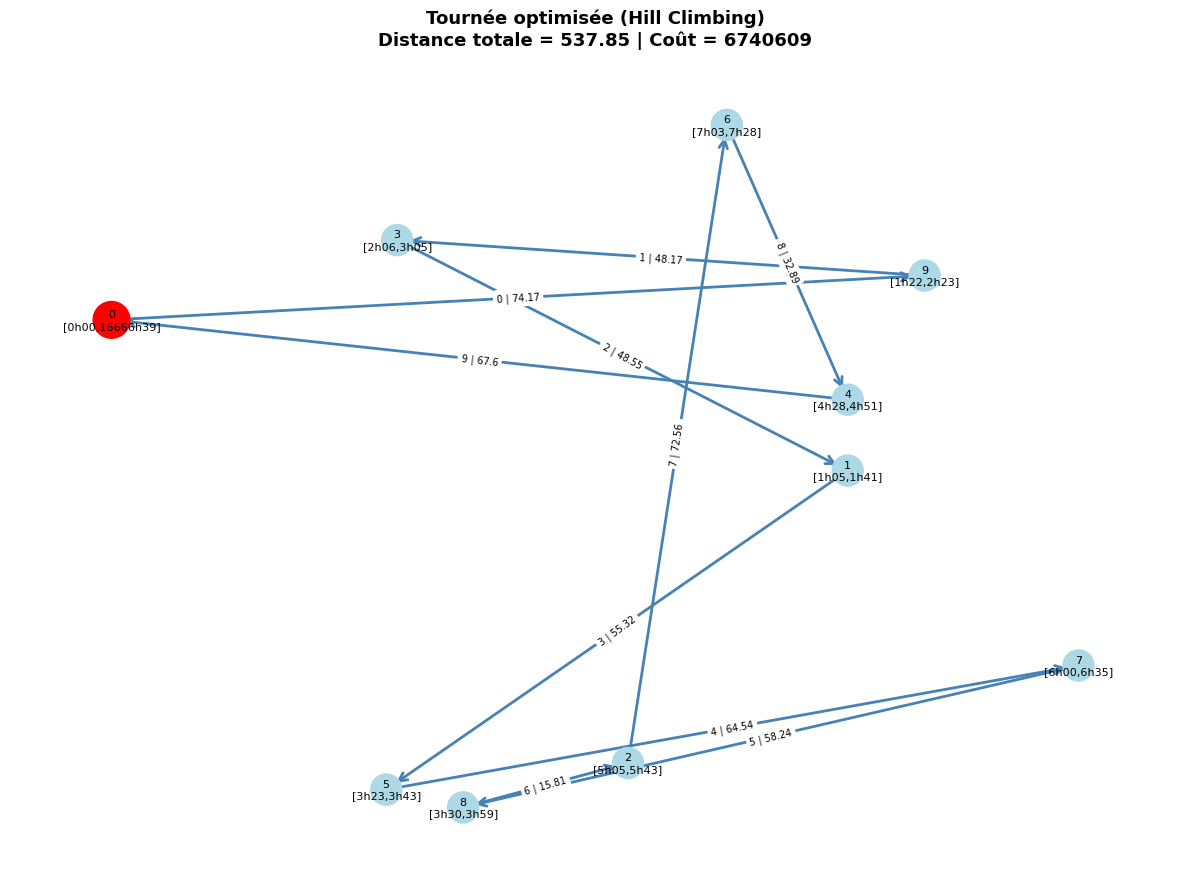

In [14]:
def hill_climbing(instance, max_iter=1000):
    """
    Optimisation par Hill Climbing (échange de deux villes).

    Args:
        instance  : dictionnaire de l'instance (utilise instance["fenetres_temps"]).
        max_iter  : nombre maximal d'itérations sans amélioration.

    Returns:
        tournee   : liste [0, v1, …, vn, 0] (avec dépôts).
        cout      : coût final.
        historique: liste des meilleurs coûts à chaque amélioration.
    """
    import random

    nb_villes        = len(instance["coordonnees"])
    tournee_courante = list(range(1, nb_villes))
    random.shuffle(tournee_courante)
    cout_courant     = evaluer_tournee(tournee_courante, instance)

    historique       = [cout_courant]
    iterations_sans_amelioration = 0

    while iterations_sans_amelioration < max_iter:
        amelioration = False

        # Parcours de tous les échanges 2-opt
        for idx1 in range(len(tournee_courante)):
            for idx2 in range(idx1 + 1, len(tournee_courante)):
                voisin           = list(tournee_courante)
                voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
                cout_voisin      = evaluer_tournee(voisin, instance)

                if cout_voisin < cout_courant:
                    tournee_courante = voisin
                    cout_courant     = cout_voisin
                    historique.append(cout_courant)
                    amelioration     = True

        if not amelioration:
            iterations_sans_amelioration += 1
        else:
            iterations_sans_amelioration = 0

    tournee_finale = [0] + tournee_courante + [0]
    return tournee_finale, cout_courant, historique

# Lancement du Hill Climbing avec les paramètres de l'instance
print("=" * 60)
print("HILL CLIMBING")
print("=" * 60)
tournee_hc, cout_hc, historique_hc = hill_climbing(data, max_iter=1000)
print(f"Meilleure tournée trouvée : {tournee_hc}")
print(f"Coût total (temps + pénalités) : {cout_hc}")
afficher_graphe(data, tournee_hc, cout=cout_hc)

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

def afficher_graphe(instance, tournee, cout=None, horaires=None):
    G = nx.DiGraph()

    coords = instance["coordonnees"]
    fenetres = horaires if horaires is not None else instance["fenetres_temps"]

    def min_to_h(minutes):
        if isinstance(minutes, (int, float)):
            h = int(minutes // 60)
            m = int(minutes % 60)
            return f"{h}h{m:02d}"
        return str(minutes)

    # Ajouter les noeuds avec positions + infos
    for i, (x, y) in coords.items():
        label = f"{i}"
        if fenetres and i in fenetres:
            ouverture, fermeture = fenetres[i]
            label += f"\n[{min_to_h(ouverture)},{min_to_h(fermeture)}]"

        G.add_node(i, pos=(x, y), label=label)

    # Ajouter les arcs avec poids + ordre
    total_distance = 0
    for i in range(len(tournee) - 1):
        u = tournee[i]
        v = tournee[i + 1]

        x1, y1 = coords[u]
        x2, y2 = coords[v]

        distance = ((x2 - x1)**2 + (y2 - y1)**2) ** 0.5
        total_distance += distance

        G.add_edge(u, v, weight=round(distance, 2), ordre=i)

    pos = nx.get_node_attributes(G, 'pos')
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(12, 9))

    # Couleur spéciale pour le dépôt
    node_colors = ["red" if n == 0 else "lightblue" for n in G.nodes()]
    node_sizes  = [700 if n == 0 else 500 for n in G.nodes()]

    # Dessin des noeuds
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors)

    # Dessin des arcs
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color="steelblue", width=2)

    # Labels des noeuds
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    # Labels des arêtes (ordre | distance)
    edge_labels = {
        (u, v): f"{d['ordre']} | {d['weight']}"
        for u, v, d in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    # Titre enrichi
    titre = "Tournée optimisée (Hill Climbing)\n"
    titre += f"Distance totale = {round(total_distance, 2)}"
    if cout is not None:
        titre += f" | Coût = {round(cout, 2)}"

    plt.title(titre, fontsize=13, fontweight="bold")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [16]:
def recuit_simule(instance, t_initial=10000, t_final=0.1, alpha=0.99, iter_par_palier=100):
    """
    Algorithme de Recuit Simulé pour le TSP avec Fenêtres de temps.
    """
    nb_villes = len(instance["coordonnees"])
    
    # 1. Génération d'une solution initiale aléatoire
    tournee_courante = list(range(1, nb_villes))
    random.shuffle(tournee_courante)
    cout_courant = evaluer_tournee(tournee_courante, instance)
    
    # On garde la trace de la meilleure solution trouvée depuis le début
    meilleure_tournee = list(tournee_courante)
    meilleur_cout = cout_courant
    
    # Historique pour le graphique de l'étude expérimentale !
    historique_couts = []
    
    temp = t_initial
    
    # 2. Boucle principale de refroidissement
    while temp > t_final:
        for _ in range(iter_par_palier):
            
            # Générer un voisin en échangeant 2 villes au hasard
            voisin = list(tournee_courante)
            idx1, idx2 = random.sample(range(len(voisin)), 2)
            voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
            
            cout_voisin = evaluer_tournee(voisin, instance)
            
            # 3. Calcul de la différence de coût
            delta = cout_voisin - cout_courant
            
            # 4. Critère d'acceptation
            # Si c'est mieux (delta < 0), ou si la probabilité l'accepte
            if delta < 0 or random.random() < math.exp(-delta / temp):
                tournee_courante = list(voisin)
                cout_courant = cout_voisin
                
                # Mise à jour du meilleur absolu
                if cout_courant < meilleur_cout:
                    meilleure_tournee = list(tournee_courante)
                    meilleur_cout = cout_courant
                    
        # On enregistre le meilleur coût à ce stade pour vos stats
        historique_couts.append(meilleur_cout)
        
        # Baisse de la température
        temp *= alpha
        
    # On rajoute les dépôts pour l'affichage final
    tournee_finale = [0] + meilleure_tournee + [0]
    
    return tournee_finale, meilleur_cout, historique_couts

In [17]:
# Lancement de l'algorithme sur l'instance 'data' générée précédemment
meilleure_tournee, cout_opt, historique = recuit_simule(data, T_INITIAL, T_FINAL, ALPHA, ITER_PAR_PALIER)

print(f"Meilleure tournée trouvée : {meilleure_tournee}")
print(f"Coût total (temps + pénalités) : {cout_opt}")

# Petit bonus pour voir si on a retrouvé la solution garantie sans pénalité
cout_solution_garantie = evaluer_tournee(data["solution_garantie"][1:-1], data)
print(f"Coût de la tournée fantôme générée initialement : {cout_solution_garantie}")

Meilleure tournée trouvée : [0, 3, 5, 8, 9, 4, 1, 2, 7, 6, 0]
Coût total (temps + pénalités) : 3770521
Coût de la tournée fantôme générée initialement : 491


In [19]:
import pulp

def resoudre_exactement_pulp(instance):
    nb_villes = len(instance["coordonnees"])
    matrice = instance["matrice_temps"]
    fenetres = instance["fenetres_temps"]

    prob = pulp.LpProblem("TSP_TimeWindows", pulp.LpMinimize)

    # Variables
    x = pulp.LpVariable.dicts("x", ((i, j) for i in range(nb_villes) for j in range(nb_villes) if i != j), cat='Binary')
    t = pulp.LpVariable.dicts("t", range(nb_villes), lowBound=0, cat='Continuous')
    t_fin = pulp.LpVariable("t_fin", lowBound=0, cat='Continuous')

    prob += t_fin

    # Contraintes de base
    prob += pulp.lpSum([x[0, j] for j in range(1, nb_villes)]) == 1
    prob += pulp.lpSum([x[i, 0] for i in range(1, nb_villes)]) == 1
    for k in range(1, nb_villes):
        prob += pulp.lpSum([x[i, k] for i in range(nb_villes) if i != k]) == 1
        prob += pulp.lpSum([x[k, j] for j in range(nb_villes) if j != k]) == 1

    # Interdire les routes bloquées
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j and matrice[i][j] == 999999:
                prob += x[i, j] == 0

    # Big M de sécurité
    M = 100000 
    
    prob += t[0] == 0
    for i in range(1, nb_villes):
        ouv, ferm = fenetres[i]
        prob += t[i] >= ouv
        prob += t[i] <= ferm

    # LA CORRECTION EST LÀ : on ignore les routes bloquées dans le MTZ
    for i in range(nb_villes):
        for j in range(1, nb_villes):
            if i != j and matrice[i][j] != 999999: 
                prob += t[j] >= t[i] + matrice[i][j] - M * (1 - x[i, j])
                
    for i in range(1, nb_villes):
        if matrice[i][0] != 999999: # ICI AUSSI
            prob += t_fin >= t[i] + matrice[i][0] - M * (1 - x[i, 0])

    # Utilisation du solveur par défaut avec message d'erreur si échec
    status = prob.solve(pulp.PULP_CBC_CMD(msg=0)) 
    
    if pulp.LpStatus[status] == "Optimal":
        ville_actuelle = 0
        tournee = [0]
        while True:
            for j in range(nb_villes):
                if ville_actuelle != j and pulp.value(x[ville_actuelle, j]) == 1:
                    tournee.append(j)
                    ville_actuelle = j
                    break
            if ville_actuelle == 0: break
        return tournee, pulp.value(t_fin), "Optimal"
    
    return None, None, pulp.LpStatus[status]

# Nouveau bloc de test
tournee, cout, statut = resoudre_exactement_pulp(data)
print(f"--- RÉSULTATS ---")
print(f"Statut réel du solveur : {statut}")
if tournee:
    print(f"Tournée : {tournee}")
    print(f"Coût : {cout}")
else:
    print("Pas de solution trouvée par PuLP.")

ModuleNotFoundError: No module named 'pulp'

In [ ]:
import matplotlib.pyplot as plt

def afficher_tournee(tournee, instance, titre="Tournée de livraison"):
    coords = instance["coordonnees"]
    matrice = instance["matrice_temps"]
    
    plt.figure(figsize=(10, 7))
    
    # 1. Dessiner les villes
    for i, (x, y) in coords.items():
        color = 'red' if i == 0 else 'blue'
        label = f"Dépôt" if i == 0 else f"Ville {i}"
        plt.scatter(x, y, c=color, s=100, zorder=5)
        plt.annotate(label, (x, y), xytext=(5, 5), textcoords='offset points')

    # 2. Dessiner les trajets
    for k in range(len(tournee) - 1):
        p1 = coords[tournee[k]]
        p2 = coords[tournee[k+1]]
        
        # Si la route est très coûteuse (Contrainte 2), on la dessine en pointillé rouge
        if matrice[tournee[k]][tournee[k+1]] >= 1000:
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', alpha=0.5)
        else:
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)

    plt.title(titre)
    plt.xlabel("Coordonnée X")
    plt.ylabel("Coordonnée Y")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Utilisation - on utilise tournee_pulp de la cellule 7
if tournee_pulp:
    afficher_tournee(tournee_pulp, data, titre="Solution Optimale (PuLP)")
else:
    # On affiche au moins la solution du recuit simulé si PuLP n'a pas marché
    afficher_tournee(meilleure_tournee, data, titre="Solution (Recuit Simulé)")